[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mihiarc/socialmapper/blob/main/docs/notebooks/09-walmart-closure-grocery-access.ipynb)

# When Walmart Closes: Grocery Access in Rural Kansas

## Modeling Grocery Store Dependency in Three Western Kansas Towns

In rural America, Walmart is not just a store -- it is infrastructure. In many small towns, the Walmart Supercenter is the only full-service grocery option within a reasonable drive. When Walmart closes a rural location (as it has done [dozens of times since 2016](https://en.wikipedia.org/wiki/Criticism_of_Walmart#Store_closings)), the community does not simply switch to a competitor. There often is no competitor. The closure creates a **food desert** overnight.

This notebook uses the same three western Kansas hub towns from [Notebook 08](08-rural-community-mapping.ipynb) -- **Hays**, **Dodge City**, and **Liberal** -- to model what happens to grocery access when Walmart disappears. We:

1. Search all shopping POIs within a 60-minute drive of each town
2. Filter to grocery-relevant stores using keyword matching
3. Analyze the drive-time distribution to expose the "dead zone" between local stores and distant alternatives
4. Quantify Walmart's share of local grocery infrastructure
5. Model a closure scenario: remove Walmart, see what remains
6. Map affected populations using census demographics
7. Calculate per-capita grocery access before and after closure

The results are sobering. In Liberal, KS, Walmart accounts for **half** of all local grocery stores. Remove it, and 69,000 people in the surrounding community lose 50% of their nearby grocery options -- with the next non-Walmart alternative 58 minutes away.

---

## Setup and Imports

In [1]:
# Uncomment to install on Google Colab:
# !pip install 'socialmapper @ git+https://github.com/mihiarc/socialmapper.git'

In [2]:
from socialmapper import (
    create_isochrone,
    get_census_blocks,
    get_census_data,
    create_map,
    get_poi,
)

import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

# Consistent plot styling
plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

---

## Step 1: Define the Three Hub Towns

We use the same three western Kansas towns from Notebook 08. These are the dominant hub towns of the Great Plains corridor, spaced 100--150 miles apart. Each serves as the primary shopping destination for a surrounding rural population that drives 30--60 minutes for groceries.

In [3]:
towns = {
    "Hays, KS":       (38.8794, -99.3268),
    "Dodge City, KS": (37.7528, -100.0171),
    "Liberal, KS":    (37.0439, -100.9210),
}

context = pd.DataFrame({
    "Town": ["Hays", "Dodge City", "Liberal"],
    "Approx. Pop.": ["~21,000", "~28,000", "~20,000"],
    "Walmart Presence": [
        "1 Supercenter",
        "1 Supercenter",
        "1 Neighborhood Market + 1 Supercenter",
    ],
    "Other Grocery": [
        "2 Dillons (Kroger)",
        "Dillons, Farmers Country Market",
        "Dillons, The Best Market",
    ],
})
display(context)

for name, (lat, lon) in towns.items():
    print(f"{name}: lat={lat}, lon={lon}")

,Town,Approx. Pop.,Walmart Presence,Other Grocery
0,Hays,"~21,000",1 Supercenter,2 Dillons (Kroger)
1,Dodge City,"~28,000",1 Supercenter,"Dillons, Farmers Country Market"
2,Liberal,"~20,000",1 Neighborhood Market + 1 Supercenter,"Dillons, The Best Market"


Hays, KS: lat=38.8794, lon=-99.3268
Dodge City, KS: lat=37.7528, lon=-100.0171
Liberal, KS: lat=37.0439, lon=-100.921


---

## Step 2: Search All Shopping POIs (60-Minute Drive)

We search the `"shopping"` category for each town with a 60-minute driving threshold. This returns all retail POIs -- supermarkets, convenience stores, clothing shops, hardware stores, everything tagged as shopping in OpenStreetMap. In the next step we will filter this broad set down to grocery-relevant stores.

We use a high limit (200) to capture as many stores as possible across the vast rural driving area.

In [4]:
all_shopping = {}

for name, coords in towns.items():
    pois = get_poi(
        coords,
        categories=["shopping"],
        travel_time=60,
        travel_mode="drive",
        limit=200,
    )
    all_shopping[name] = pois
    print(f"{name}: {len(pois)} shopping POIs within 60-min drive")
    time.sleep(10)  # Rate-limit courtesy pause (Valhalla isochrone runs internally)

Hays, KS: 72 shopping POIs within 60-min drive


Dodge City, KS: 49 shopping POIs within 60-min drive


Liberal, KS: 57 shopping POIs within 60-min drive


---

## Step 3: Filter to Grocery Stores

Not every shopping POI sells food. We need to separate grocery stores from clothing shops, hardware stores, and gas stations. The filter uses keyword matching against store names -- intentionally broad to catch small-town stores with names like "Farmers Country Market" or "Wilson Family Foods" that would not match a simple "grocery" search.

### Grocery keyword list

```
walmart, supercenter, neighborhood market, dillons, kroger, aldi,
save-a-lot, grocery, supermarket, food store, food center, food shop,
foods, market
```

The keyword `"market"` is intentionally included despite being ambiguous (it also matches "flea market") because in rural Kansas, stores named "Harvest Market" or "Main Street Market" are genuine grocery outlets. We accept some false positives to avoid missing critical small-town stores.

In [5]:
GROCERY_KEYWORDS = [
    "walmart", "supercenter", "neighborhood market",
    "dillons", "kroger", "aldi", "save-a-lot",
    "grocery", "supermarket",
    "food store", "food center", "food shop", "foods",
    "market",
]


def is_grocery(poi_name):
    """Check if a POI name matches any grocery keyword."""
    name_lower = poi_name.lower()
    return any(kw in name_lower for kw in GROCERY_KEYWORDS)


def is_walmart(poi_name):
    """Check if a POI is a Walmart store."""
    name_lower = poi_name.lower()
    return "walmart" in name_lower or "wal-mart" in name_lower


grocery_stores = {}

for name in towns:
    stores = [p for p in all_shopping[name] if is_grocery(p["name"])]
    grocery_stores[name] = stores

    print(f"\n{'=' * 60}")
    print(f"{name}: {len(stores)} grocery stores within 60-min drive")
    print(f"{'=' * 60}")
    print(f"  {'Store':<40} {'Drive (min)':>10}  {'Walmart?'}")
    print(f"  {'-'*40} {'-'*10}  {'-'*8}")
    for s in stores:
        t = s.get("travel_time_minutes", "?")
        label = f"{t:.1f}" if isinstance(t, (int, float)) else str(t)
        wm = "YES" if is_walmart(s["name"]) else ""
        print(f"  {s['name'][:39]:<40} {label:>10}  {wm}")


Hays, KS: 10 grocery stores within 60-min drive
  Store                                    Drive (min)  Walmart?
  ---------------------------------------- ----------  --------
  Dillons                                         4.1  
  Dillons                                         4.2  
  Walmart Vision Center                           6.5  YES
  Walmart Supercenter                             6.7  YES
  Rick's Food Store                              27.1  
  Main Street Market                             33.9  
  J-Mart Food Shop                               40.5  
  Wilson Family Foods                            48.2  
  Town and Country Supermarket                   55.7  
  Dillons                                        60.7  

Dodge City, KS: 12 grocery stores within 60-min drive
  Store                                    Drive (min)  Walmart?
  ---------------------------------------- ----------  --------
  Farmers Country Market                          2.9  
  Dillons       

### What the Grocery Inventory Reveals

The filtered results expose the thin grocery infrastructure of rural Kansas:

- **Hays** has a cluster of stores within 10 minutes (including 2 Dillons and a Walmart Supercenter), then scattered small-town stores at 27--56 minutes
- **Dodge City** shows the same pattern: 3 local stores (Farmers Country Market, Dillons, Walmart), then a handful of distant options
- **Liberal** is the most isolated: 4 local stores include 2 Walmarts (a Neighborhood Market and a Supercenter), then **nothing until 44 minutes** when Guymon, OK comes into range

The grocery landscape is not a smooth gradient from close to far. It is **clustered**: a few stores in town, a vast empty zone, then a few more stores in the next town over. This clustering is the core vulnerability.

---

## Step 4: Time-Band Analysis -- The Dead Zone

To visualize the clustering pattern, we bucket grocery stores into 10-minute time bands. This exposes the **dead zone** -- the gap between local stores (0--10 minutes) and distant alternatives (30+ minutes) where no grocery stores exist.

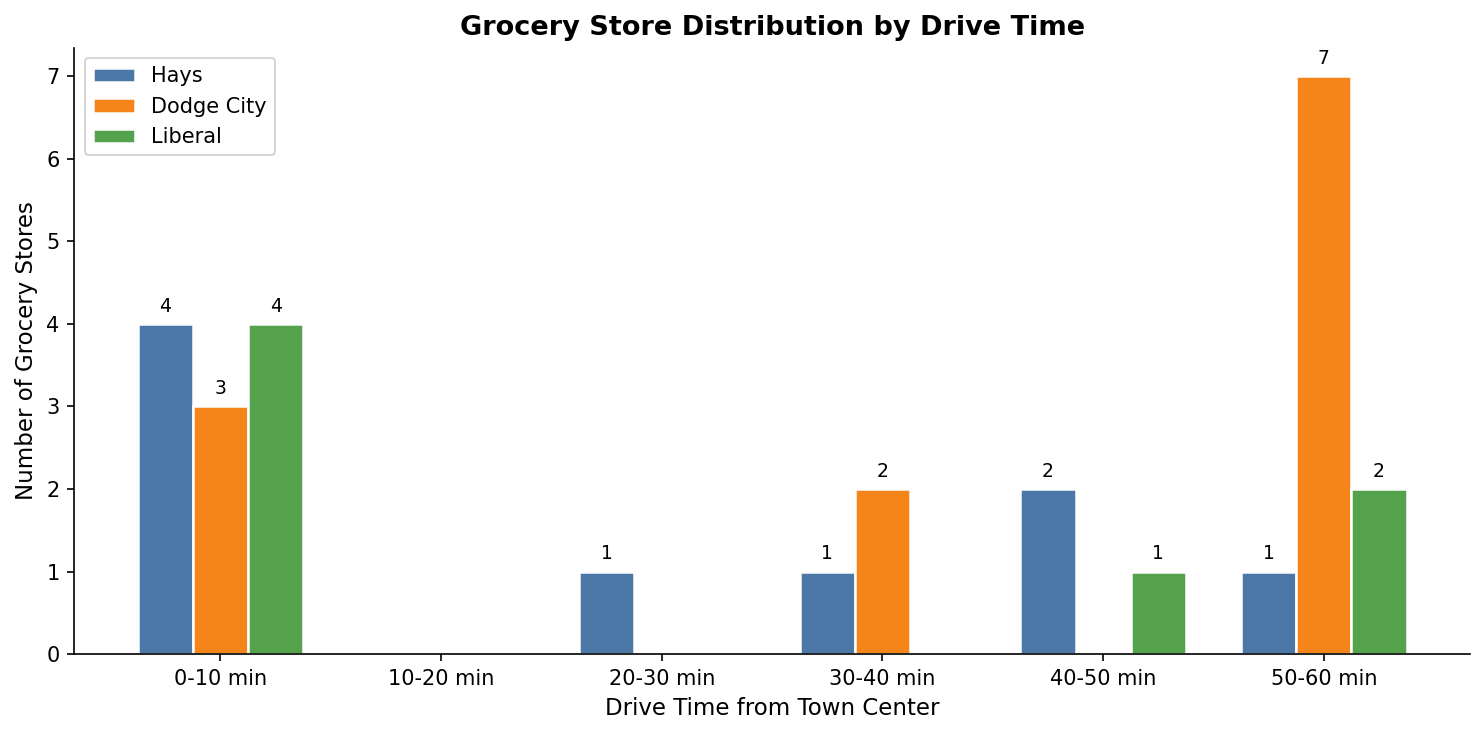

Hays, KS: 4 local (0-10 min), 1 mid-range (10-30 min), 4 distant (30-60 min)
Dodge City, KS: 3 local (0-10 min), 0 mid-range (10-30 min), 9 distant (30-60 min)
Liberal, KS: 4 local (0-10 min), 0 mid-range (10-30 min), 3 distant (30-60 min)


In [6]:
time_bands = ["0-10", "10-20", "20-30", "30-40", "40-50", "50-60"]
band_edges = [(0, 10), (10, 20), (20, 30), (30, 40), (40, 50), (50, 60)]

band_counts = {}
for name in towns:
    counts = []
    for low, high in band_edges:
        n = sum(
            1 for s in grocery_stores[name]
            if s.get("travel_time_minutes") is not None
            and low < s["travel_time_minutes"] <= high
        )
        # Include 0 in the first band
        if low == 0:
            n = sum(
                1 for s in grocery_stores[name]
                if s.get("travel_time_minutes") is not None
                and s["travel_time_minutes"] <= high
            )
        counts.append(n)
    band_counts[name] = counts

# Grouped bar chart
town_names_short = [n.replace(", KS", "") for n in towns]
colors = ["#4c78a8", "#f58518", "#54a24b"]
x = np.arange(len(time_bands))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, color) in enumerate(zip(towns, colors)):
    vals = band_counts[name]
    bars = ax.bar(x + i * width, vals, width,
                  label=name.replace(", KS", ""),
                  color=color, edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                    str(val), ha="center", va="bottom", fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels([f"{b} min" for b in time_bands])
ax.set_xlabel("Drive Time from Town Center")
ax.set_ylabel("Number of Grocery Stores")
ax.set_title("Grocery Store Distribution by Drive Time", fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Print the dead zone
for name in towns:
    local = band_counts[name][0]  # 0-10 min
    mid = sum(band_counts[name][1:3])  # 10-30 min
    distant = sum(band_counts[name][3:])  # 30-60 min
    print(f"{name}: {local} local (0-10 min), {mid} mid-range (10-30 min), {distant} distant (30-60 min)")

### The Dead Zone

The chart makes the pattern unmistakable. For all three towns, grocery stores cluster in the **0--10 minute band** (the town itself), then drop to near-zero in the 10--30 minute range, with a few scattered stores reappearing at 30+ minutes in neighboring small towns.

This is the dead zone: the 20-minute gap between your town and the next town with a grocery store. If you live in the town, you have options. If you live 15 minutes outside of town -- on a farm, in a small unincorporated settlement -- you are already in the dead zone.

The dead zone is especially dangerous for Liberal. After the local cluster of 4 stores, the next grocery option is over 40 minutes away in Guymon, Oklahoma. For Hays and Dodge City, a few small-town stores in the 27--35 minute range provide a thin safety net -- but those stores are themselves fragile small businesses.

---

## Step 5: Walmart Dependency -- How Much of Local Grocery Is Walmart?

Now we quantify the core question: of the grocery stores within easy reach (10 minutes or less), how many are Walmart? This fraction tells us how dependent each town is on a single corporation for its food supply.


Hays, KS:
  Local grocery stores (within 10 min): 4
  Walmart stores:     2 (50%)
  Non-Walmart stores: 2
  Walmart:     Walmart Vision Center, Walmart Supercenter
  Non-Walmart: Dillons, Dillons

Dodge City, KS:
  Local grocery stores (within 10 min): 3
  Walmart stores:     1 (33%)
  Non-Walmart stores: 2
  Walmart:     Walmart Supercenter
  Non-Walmart: Farmers Country Market, Dillons

Liberal, KS:
  Local grocery stores (within 10 min): 4
  Walmart stores:     2 (50%)
  Non-Walmart stores: 2
  Walmart:     Walmart Neighborhood Market, Walmart Supercenter
  Non-Walmart: Dillons, The Best Market


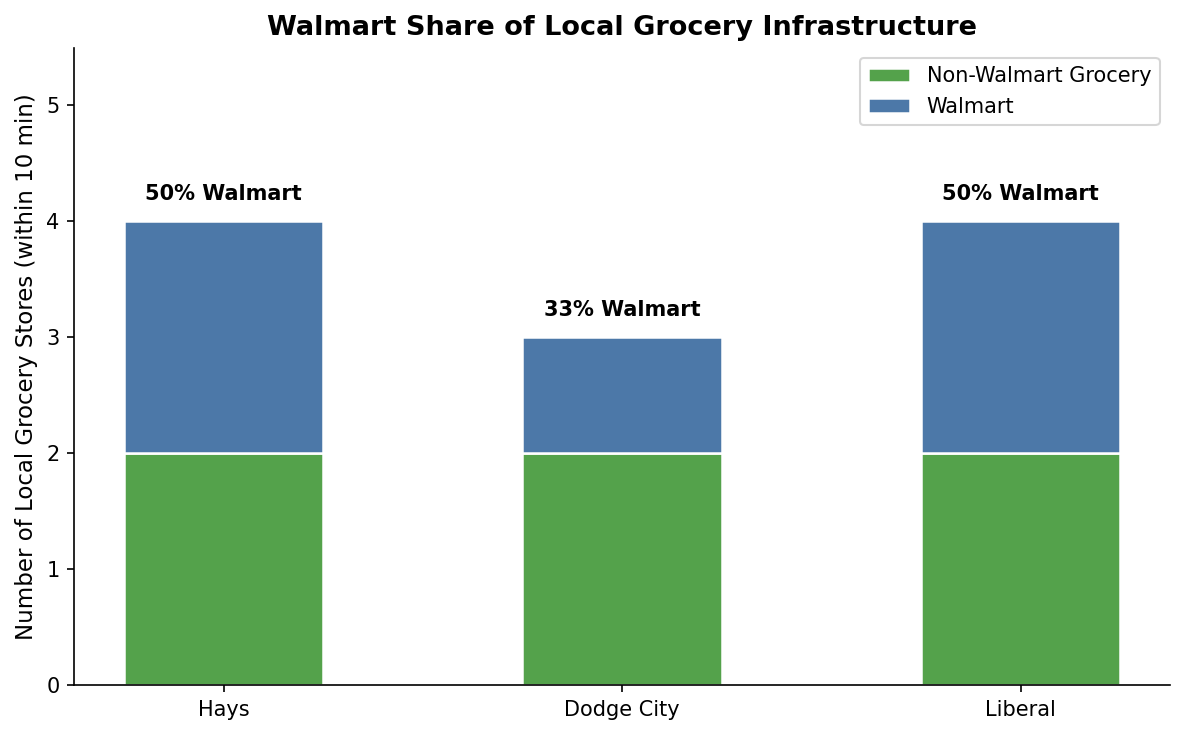

In [7]:
dependency = {}

for name in towns:
    local_stores = [
        s for s in grocery_stores[name]
        if s.get("travel_time_minutes") is not None
        and s["travel_time_minutes"] <= 10
    ]
    walmart_local = [s for s in local_stores if is_walmart(s["name"])]
    non_walmart_local = [s for s in local_stores if not is_walmart(s["name"])]

    total = len(local_stores)
    wm_count = len(walmart_local)
    pct = (wm_count / total * 100) if total > 0 else 0

    dependency[name] = {
        "total_local": total,
        "walmart_count": wm_count,
        "non_walmart_count": len(non_walmart_local),
        "walmart_pct": pct,
        "walmart_stores": [s["name"] for s in walmart_local],
        "non_walmart_stores": [s["name"] for s in non_walmart_local],
    }

    print(f"\n{name}:")
    print(f"  Local grocery stores (within 10 min): {total}")
    print(f"  Walmart stores:     {wm_count} ({pct:.0f}%)")
    print(f"  Non-Walmart stores: {len(non_walmart_local)}")
    print(f"  Walmart:     {', '.join(s['name'] for s in walmart_local) or 'none'}")
    print(f"  Non-Walmart: {', '.join(s['name'] for s in non_walmart_local) or 'none'}")

# Stacked bar chart
fig, ax = plt.subplots(figsize=(8, 5))
town_labels = [n.replace(", KS", "") for n in towns]
walmart_vals = [dependency[n]["walmart_count"] for n in towns]
non_walmart_vals = [dependency[n]["non_walmart_count"] for n in towns]
x = np.arange(len(town_labels))

bars_nw = ax.bar(x, non_walmart_vals, 0.5, label="Non-Walmart Grocery",
                 color="#54a24b", edgecolor="white", linewidth=1.2)
bars_wm = ax.bar(x, walmart_vals, 0.5, bottom=non_walmart_vals,
                 label="Walmart", color="#4c78a8", edgecolor="white", linewidth=1.2)

for i, name in enumerate(towns):
    total = dependency[name]["total_local"]
    pct = dependency[name]["walmart_pct"]
    ax.text(i, total + 0.15, f"{pct:.0f}% Walmart",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(town_labels)
ax.set_ylabel("Number of Local Grocery Stores (within 10 min)")
ax.set_title("Walmart Share of Local Grocery Infrastructure", fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, max(dependency[n]["total_local"] for n in towns) + 1.5)
plt.tight_layout()
plt.show()

### What the Dependency Data Shows

The stacked bar chart quantifies what locals already know:

- **Dodge City**: Walmart represents about one-third of local grocery infrastructure (1 out of 3 stores). The remaining two-thirds are Dillons (Kroger subsidiary) and an independent store. Losing Walmart would hurt, but alternatives exist within town.

- **Hays and Liberal**: Walmart accounts for **half** of local grocery stores. In Hays, this includes both the Supercenter and a Walmart Vision Center (which the keyword filter catches). In Liberal, it is a Neighborhood Market and a Supercenter. If both close, each town drops from 4 local grocery stores to 2.

- **Liberal is the most exposed** because, unlike Hays, the next nearest grocery options are over 44 minutes away -- not 27 minutes.

This is not hypothetical. Walmart has closed rural locations before, sometimes with as little as two months' notice. When it closes a Supercenter, the community loses not just a grocery store but also a pharmacy, tire center, eye care clinic, and the only place to buy household goods at scale.

---

## Step 6: Closure Scenario -- What Remains Without Walmart?

We now model a closure scenario. For each town, we remove all Walmart stores from the grocery inventory and compare the before and after counts -- both for local stores (within 10 minutes) and for the entire 60-minute driving area.


Hays, KS:
  Total grocery (60-min): 10 -> 8 (lost 2)
  Local grocery (10-min): 4 -> 2 (lost 2)
  Nearest non-Walmart beyond 10 min: Rick's Food Store (27.1 min)
  Remaining local stores: Dillons, Dillons

Dodge City, KS:
  Total grocery (60-min): 12 -> 9 (lost 3)
  Local grocery (10-min): 3 -> 2 (lost 1)
  Nearest non-Walmart beyond 10 min: Harvest Market (30.3 min)
  Remaining local stores: Farmers Country Market, Dillons

Liberal, KS:
  Total grocery (60-min): 7 -> 4 (lost 3)
  Local grocery (10-min): 4 -> 2 (lost 2)
  Nearest non-Walmart beyond 10 min: Lowe's Market (58.3 min)
  Remaining local stores: Dillons, The Best Market


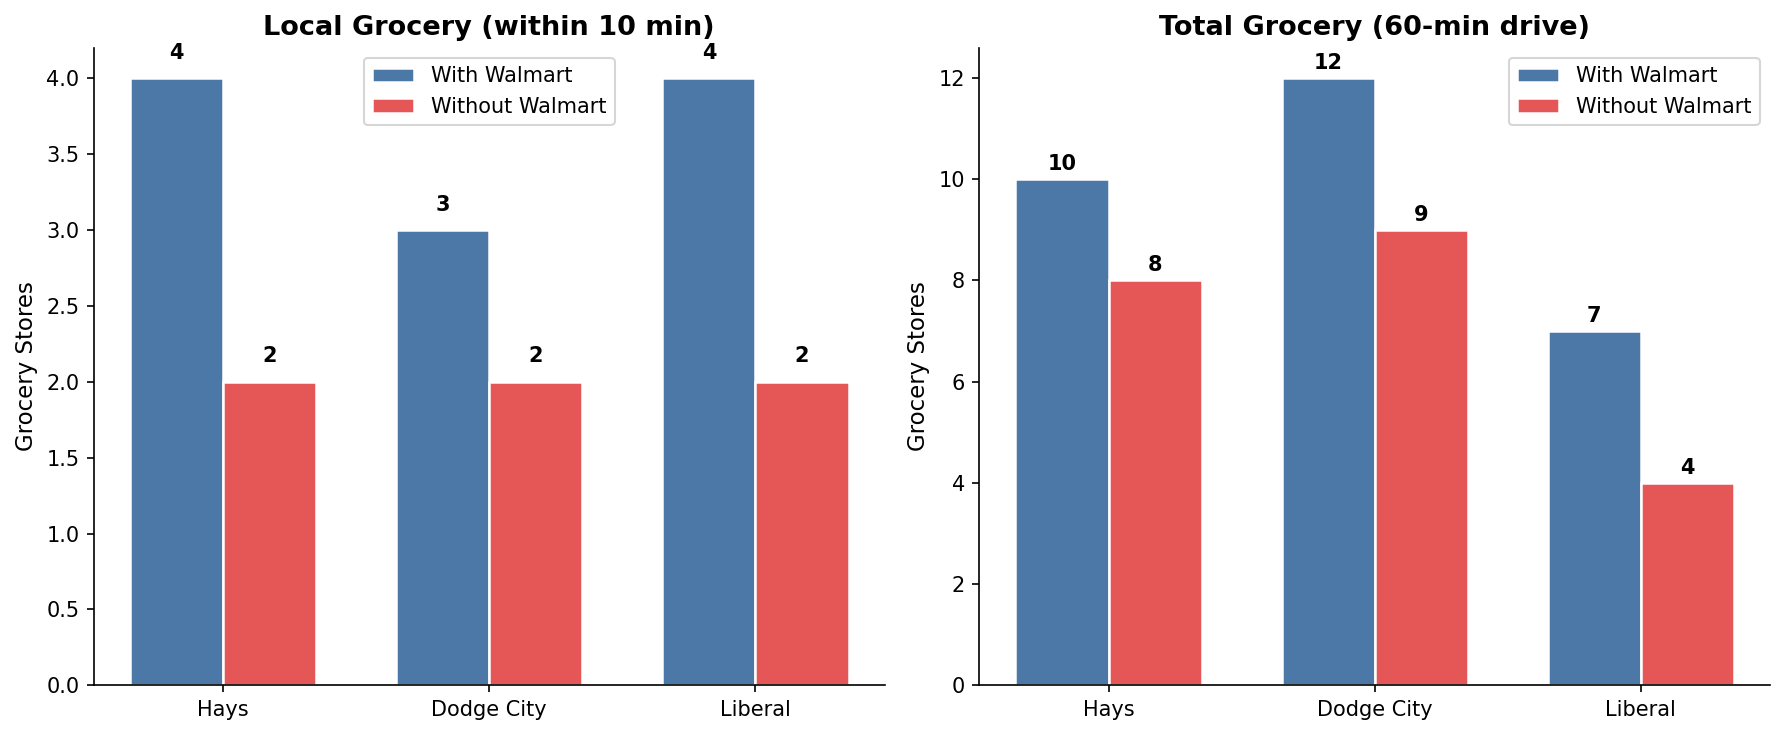

In [8]:
closure = {}

for name in towns:
    all_grocery = grocery_stores[name]
    after_closure = [s for s in all_grocery if not is_walmart(s["name"])]

    local_before = [
        s for s in all_grocery
        if s.get("travel_time_minutes") is not None
        and s["travel_time_minutes"] <= 10
    ]
    local_after = [s for s in local_before if not is_walmart(s["name"])]

    # Find nearest non-Walmart store after the local cluster
    distant_non_walmart = [
        s for s in after_closure
        if s.get("travel_time_minutes") is not None
        and s["travel_time_minutes"] > 10
    ]
    nearest_distant = distant_non_walmart[0] if distant_non_walmart else None

    closure[name] = {
        "total_before": len(all_grocery),
        "total_after": len(after_closure),
        "local_before": len(local_before),
        "local_after": len(local_after),
        "nearest_distant": nearest_distant,
    }

    print(f"\n{name}:")
    print(f"  Total grocery (60-min): {len(all_grocery)} -> {len(after_closure)} (lost {len(all_grocery) - len(after_closure)})")
    print(f"  Local grocery (10-min): {len(local_before)} -> {len(local_after)} (lost {len(local_before) - len(local_after)})")
    if nearest_distant:
        t = nearest_distant.get("travel_time_minutes", "?")
        print(f"  Nearest non-Walmart beyond 10 min: {nearest_distant['name']} ({t:.1f} min)")
    print(f"  Remaining local stores: {', '.join(s['name'] for s in local_after) or 'NONE'}")

# Before/after paired bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Local stores (within 10 min)
town_labels = [n.replace(", KS", "") for n in towns]
x = np.arange(len(town_labels))
width = 0.35

before_local = [closure[n]["local_before"] for n in towns]
after_local = [closure[n]["local_after"] for n in towns]

bars1 = axes[0].bar(x - width / 2, before_local, width, label="With Walmart",
                    color="#4c78a8", edgecolor="white", linewidth=1.2)
bars2 = axes[0].bar(x + width / 2, after_local, width, label="Without Walmart",
                    color="#e45756", edgecolor="white", linewidth=1.2)
for bar, val in zip(bars1, before_local):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar, val in zip(bars2, after_local):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(town_labels)
axes[0].set_ylabel("Grocery Stores")
axes[0].set_title("Local Grocery (within 10 min)", fontweight="bold")
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

# Total stores (60-min area)
before_total = [closure[n]["total_before"] for n in towns]
after_total = [closure[n]["total_after"] for n in towns]

bars3 = axes[1].bar(x - width / 2, before_total, width, label="With Walmart",
                    color="#4c78a8", edgecolor="white", linewidth=1.2)
bars4 = axes[1].bar(x + width / 2, after_total, width, label="Without Walmart",
                    color="#e45756", edgecolor="white", linewidth=1.2)
for bar, val in zip(bars3, before_total):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar, val in zip(bars4, after_total):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(town_labels)
axes[1].set_ylabel("Grocery Stores")
axes[1].set_title("Total Grocery (60-min drive)", fontweight="bold")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### The Closure Impact

The before/after comparison reveals the asymmetric impact:

- **Dodge City** loses 1 local store (from 3 to 2). Painful, but Dillons and Farmers Country Market provide a fallback. Competition disappears, but food access survives.

- **Hays** drops from 4 to 2 local stores. However, Rick's Food Store at 27 minutes provides a mid-range fallback -- not convenient for weekly shopping, but not as catastrophic as Liberal's situation.

- **Liberal loses half its local grocery infrastructure** (from 4 to 2). The remaining Dillons and The Best Market are smaller stores with less selection and higher prices. And the next non-local option is a 58-minute drive to Lowe's Market -- with the only closer alternative being a Walmart Supercenter in Guymon, Oklahoma at 44 minutes (which would also close in a regional Walmart pullback).

The 60-minute view tells a similar story but includes distant small-town stores that are not practical for weekly grocery shopping. Nobody drives 48 minutes to Wilson Family Foods for milk.

---

## Step 7: Who Is Affected? Isochrones and Census Demographics

To understand the human impact, we generate 60-minute driving isochrones and pull census demographics for each town. This tells us how many people live within each town's grocery service area, their income levels, and their poverty rates.

In [9]:
isochrones = {}
census_data = {}
merged_data = {}

demographic_variables = ["population", "median_income", "poverty"]

for name, coords in towns.items():
    # Generate isochrone
    iso = create_isochrone(coords, travel_time=60, travel_mode="drive")
    isochrones[name] = iso
    print(f"{name}: {iso['properties']['area_sq_km']:.0f} sq km")
    time.sleep(10)  # Rate-limit courtesy pause

    # Fetch census block groups
    blocks = get_census_blocks(polygon=iso)

    # Fetch demographics
    census = get_census_data(iso, variables=demographic_variables)

    # Merge
    merged = []
    for block in blocks:
        geoid = block["geoid"]
        if geoid in census.data:
            merged.append({**block, **census.data[geoid]})

    census_data[name] = census
    merged_data[name] = merged

    total_pop = sum(
        d.get("population", 0)
        for d in census.data.values()
        if d.get("population") is not None
    )
    incomes = [
        d["median_income"]
        for d in census.data.values()
        if d.get("median_income") is not None and d["median_income"] > 0
    ]
    avg_income = sum(incomes) / len(incomes) if incomes else 0
    total_poverty = sum(
        d.get("poverty", 0)
        for d in census.data.values()
        if d.get("poverty") is not None
    )
    poverty_rate = (total_poverty / total_pop * 100) if total_pop > 0 else 0

    print(f"  Population:     {total_pop:,}")
    print(f"  Avg. income:    ${avg_income:,.0f}")
    print(f"  Poverty rate:   {poverty_rate:.1f}%")
    print()

Hays, KS: 10855 sq km


  Population:     60,725.0
  Avg. income:    $67,571
  Poverty rate:   13.2%



Dodge City, KS: 12919 sq km


  Population:     88,678.0
  Avg. income:    $75,661
  Poverty rate:   12.0%



Liberal, KS: 10268 sq km


  Population:     69,195.0
  Avg. income:    $68,789
  Poverty rate:   14.2%



### The Affected Communities

The census data grounds the closure scenario in human terms:

- **Hays**: ~61,000 people with ~$68,000 avg. median income and ~13% poverty
- **Dodge City**: ~89,000 people with ~$76,000 avg. median income and ~12% poverty
- **Liberal**: ~69,000 people with ~$69,000 avg. median income and ~14% poverty

Liberal's combination of the highest poverty rate and the highest Walmart dependency makes it the most vulnerable. Low-income households are least able to absorb the costs of driving further for groceries or paying higher prices at remaining stores.

---

## Step 8: Map Grocery Access -- Population Choropleths with Store Overlays

These maps show where people live (population by block group) with grocery store locations overlaid as points. The dashed boundary marks the 60-minute driving isochrone. This spatial view reveals that grocery stores cluster in the town center while the vast surrounding area -- where thousands of people live spread thin -- has no stores at all.


--- Hays, KS (10 grocery stores shown) ---


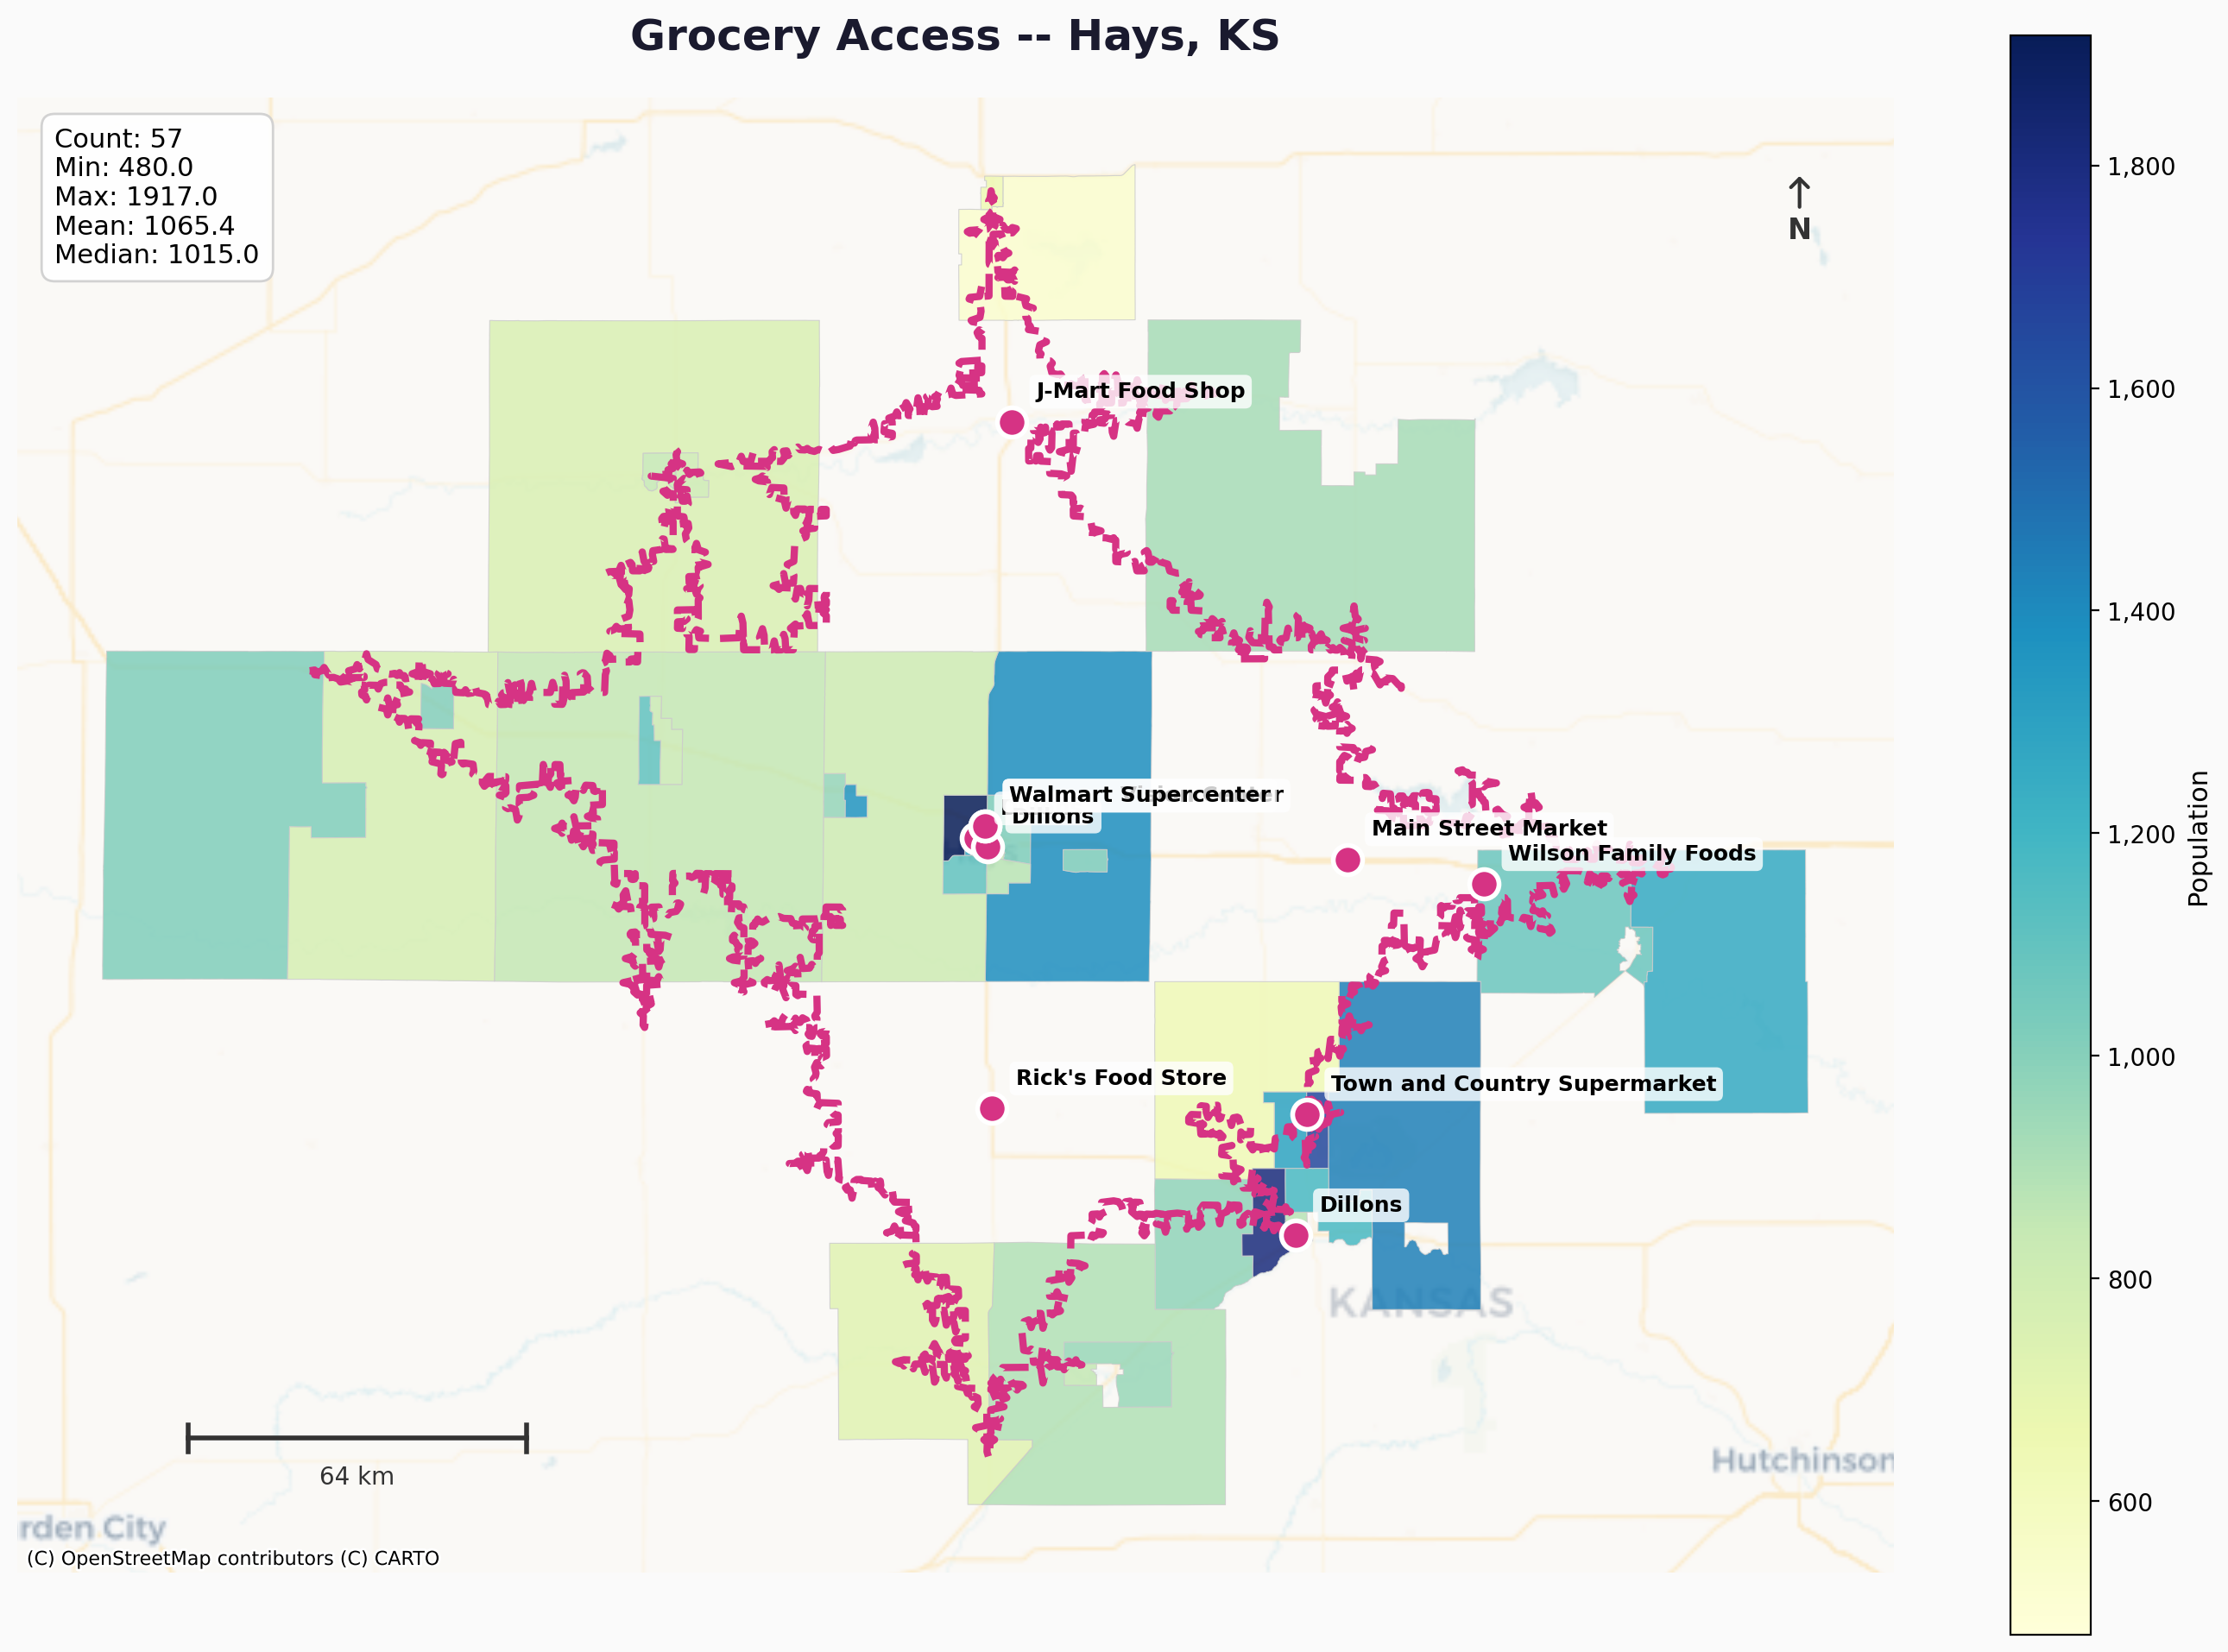


--- Dodge City, KS (12 grocery stores shown) ---


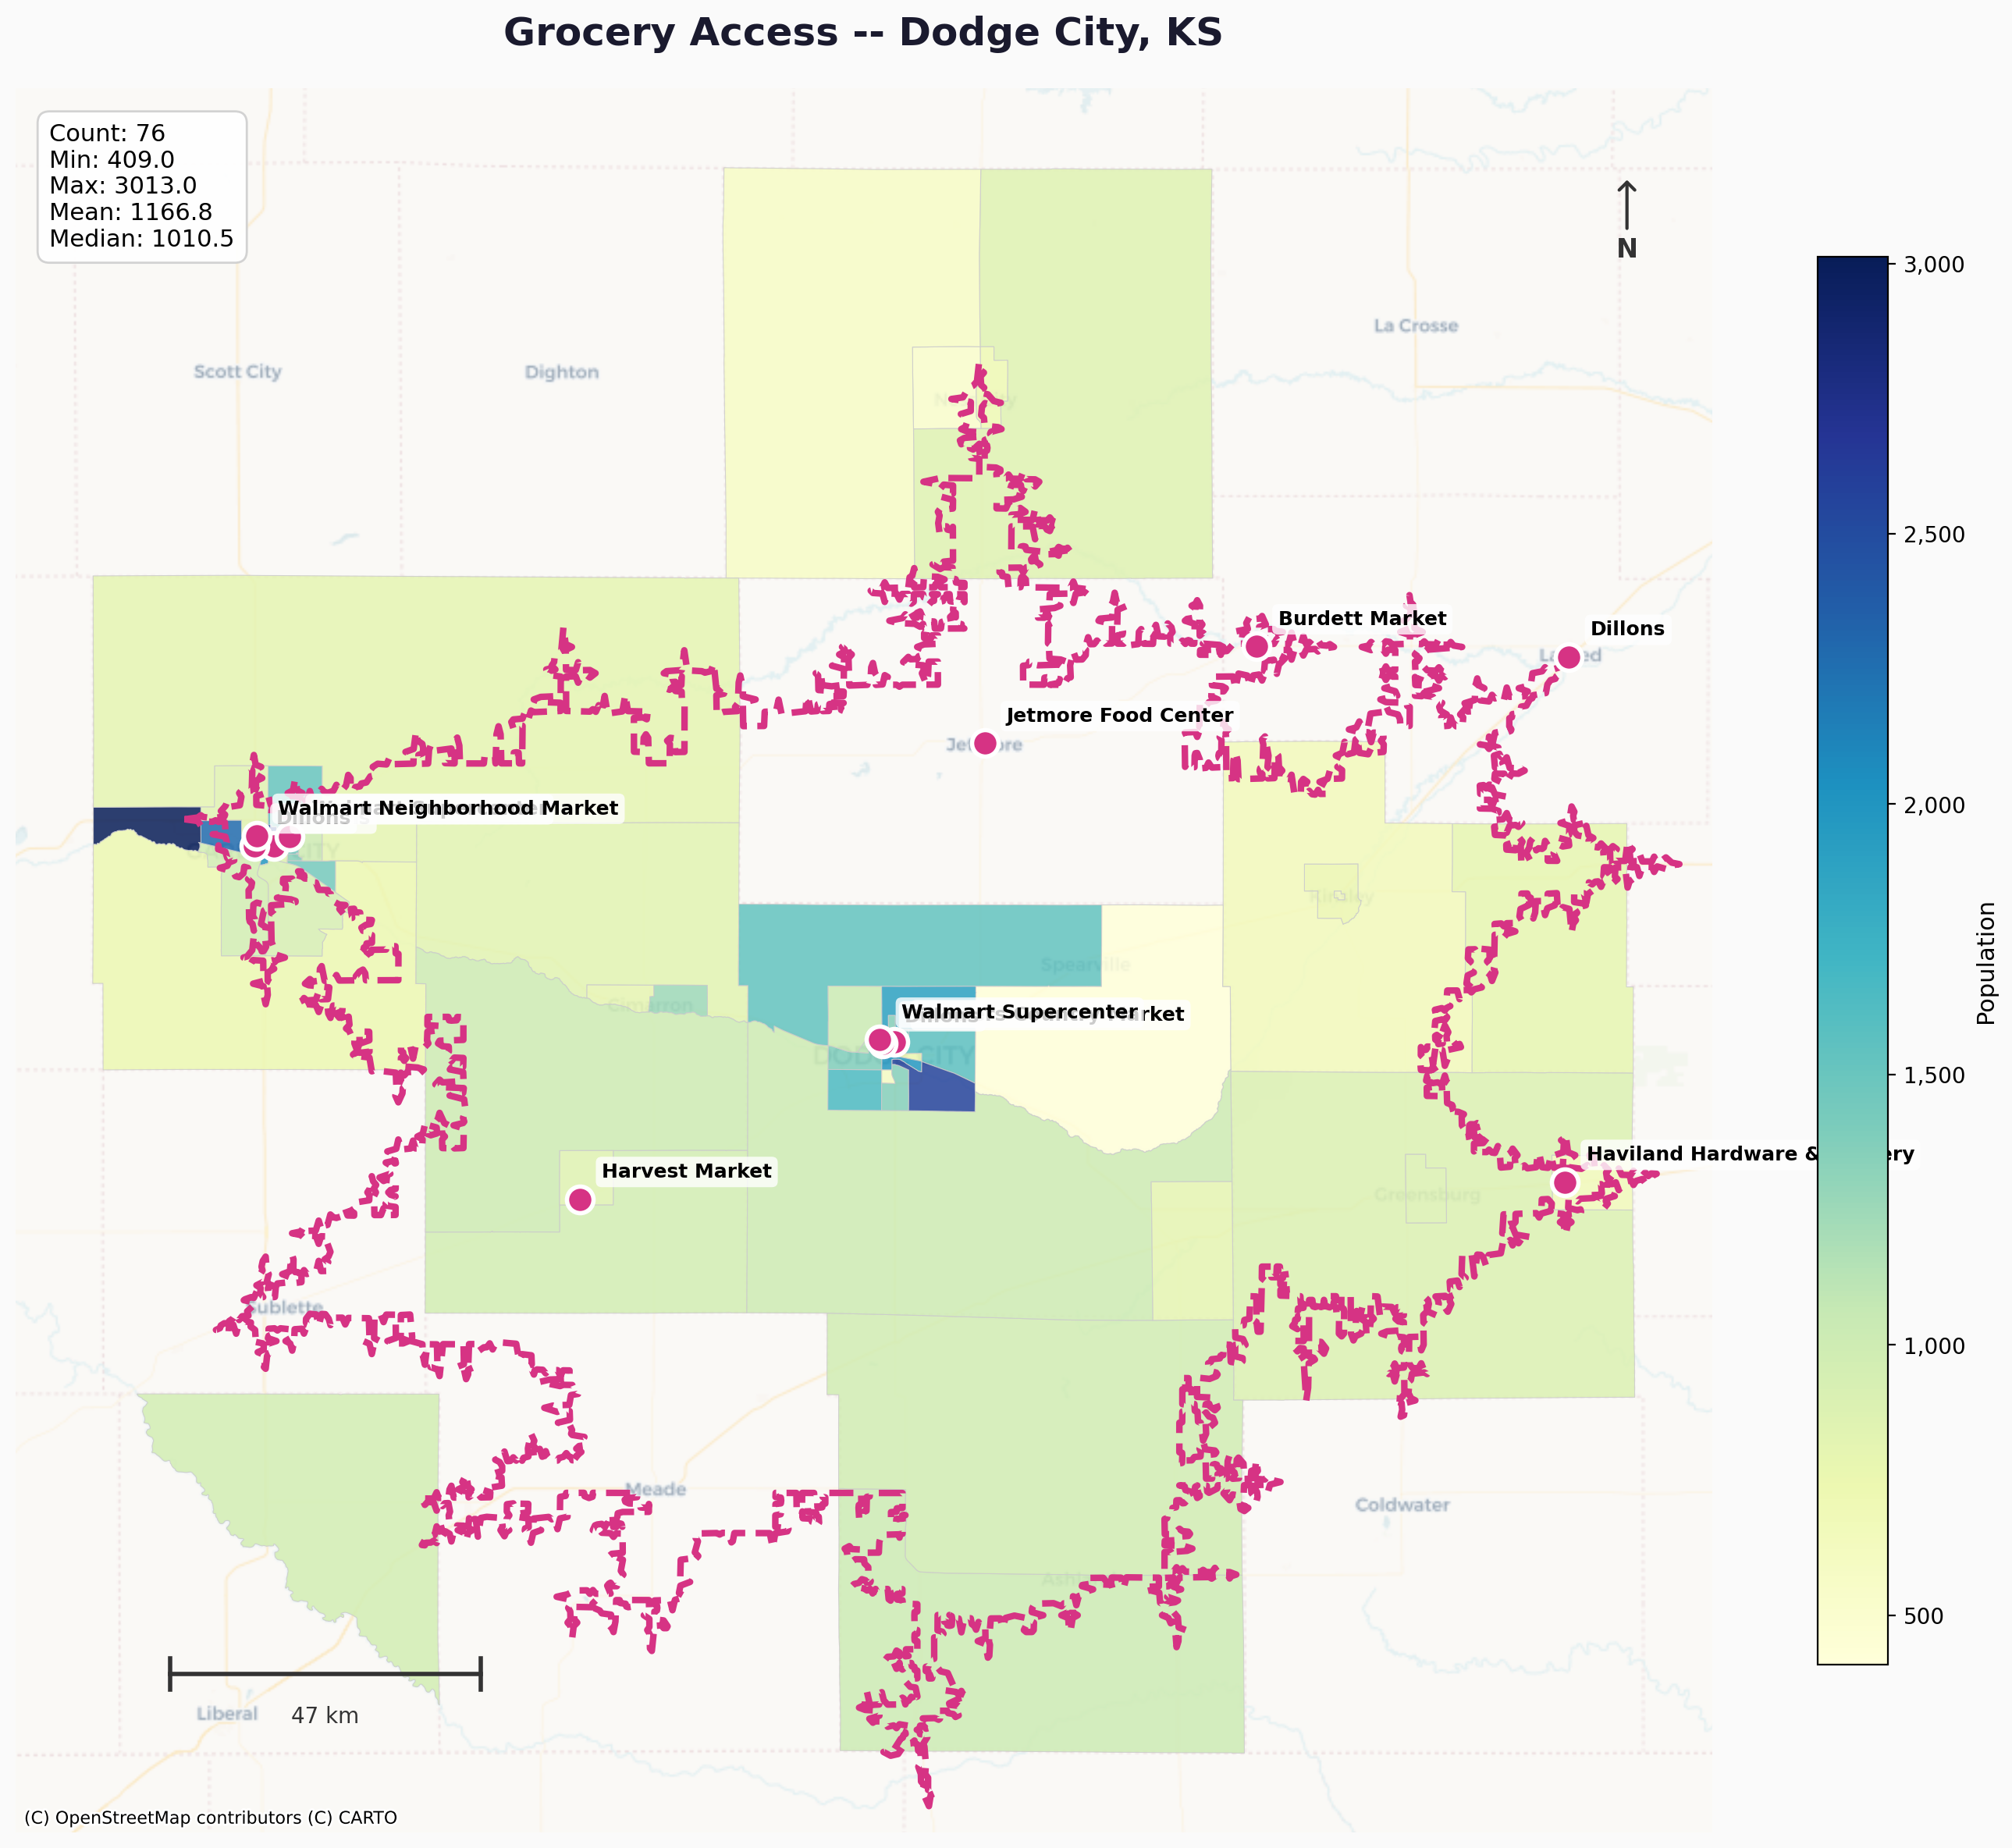


--- Liberal, KS (7 grocery stores shown) ---


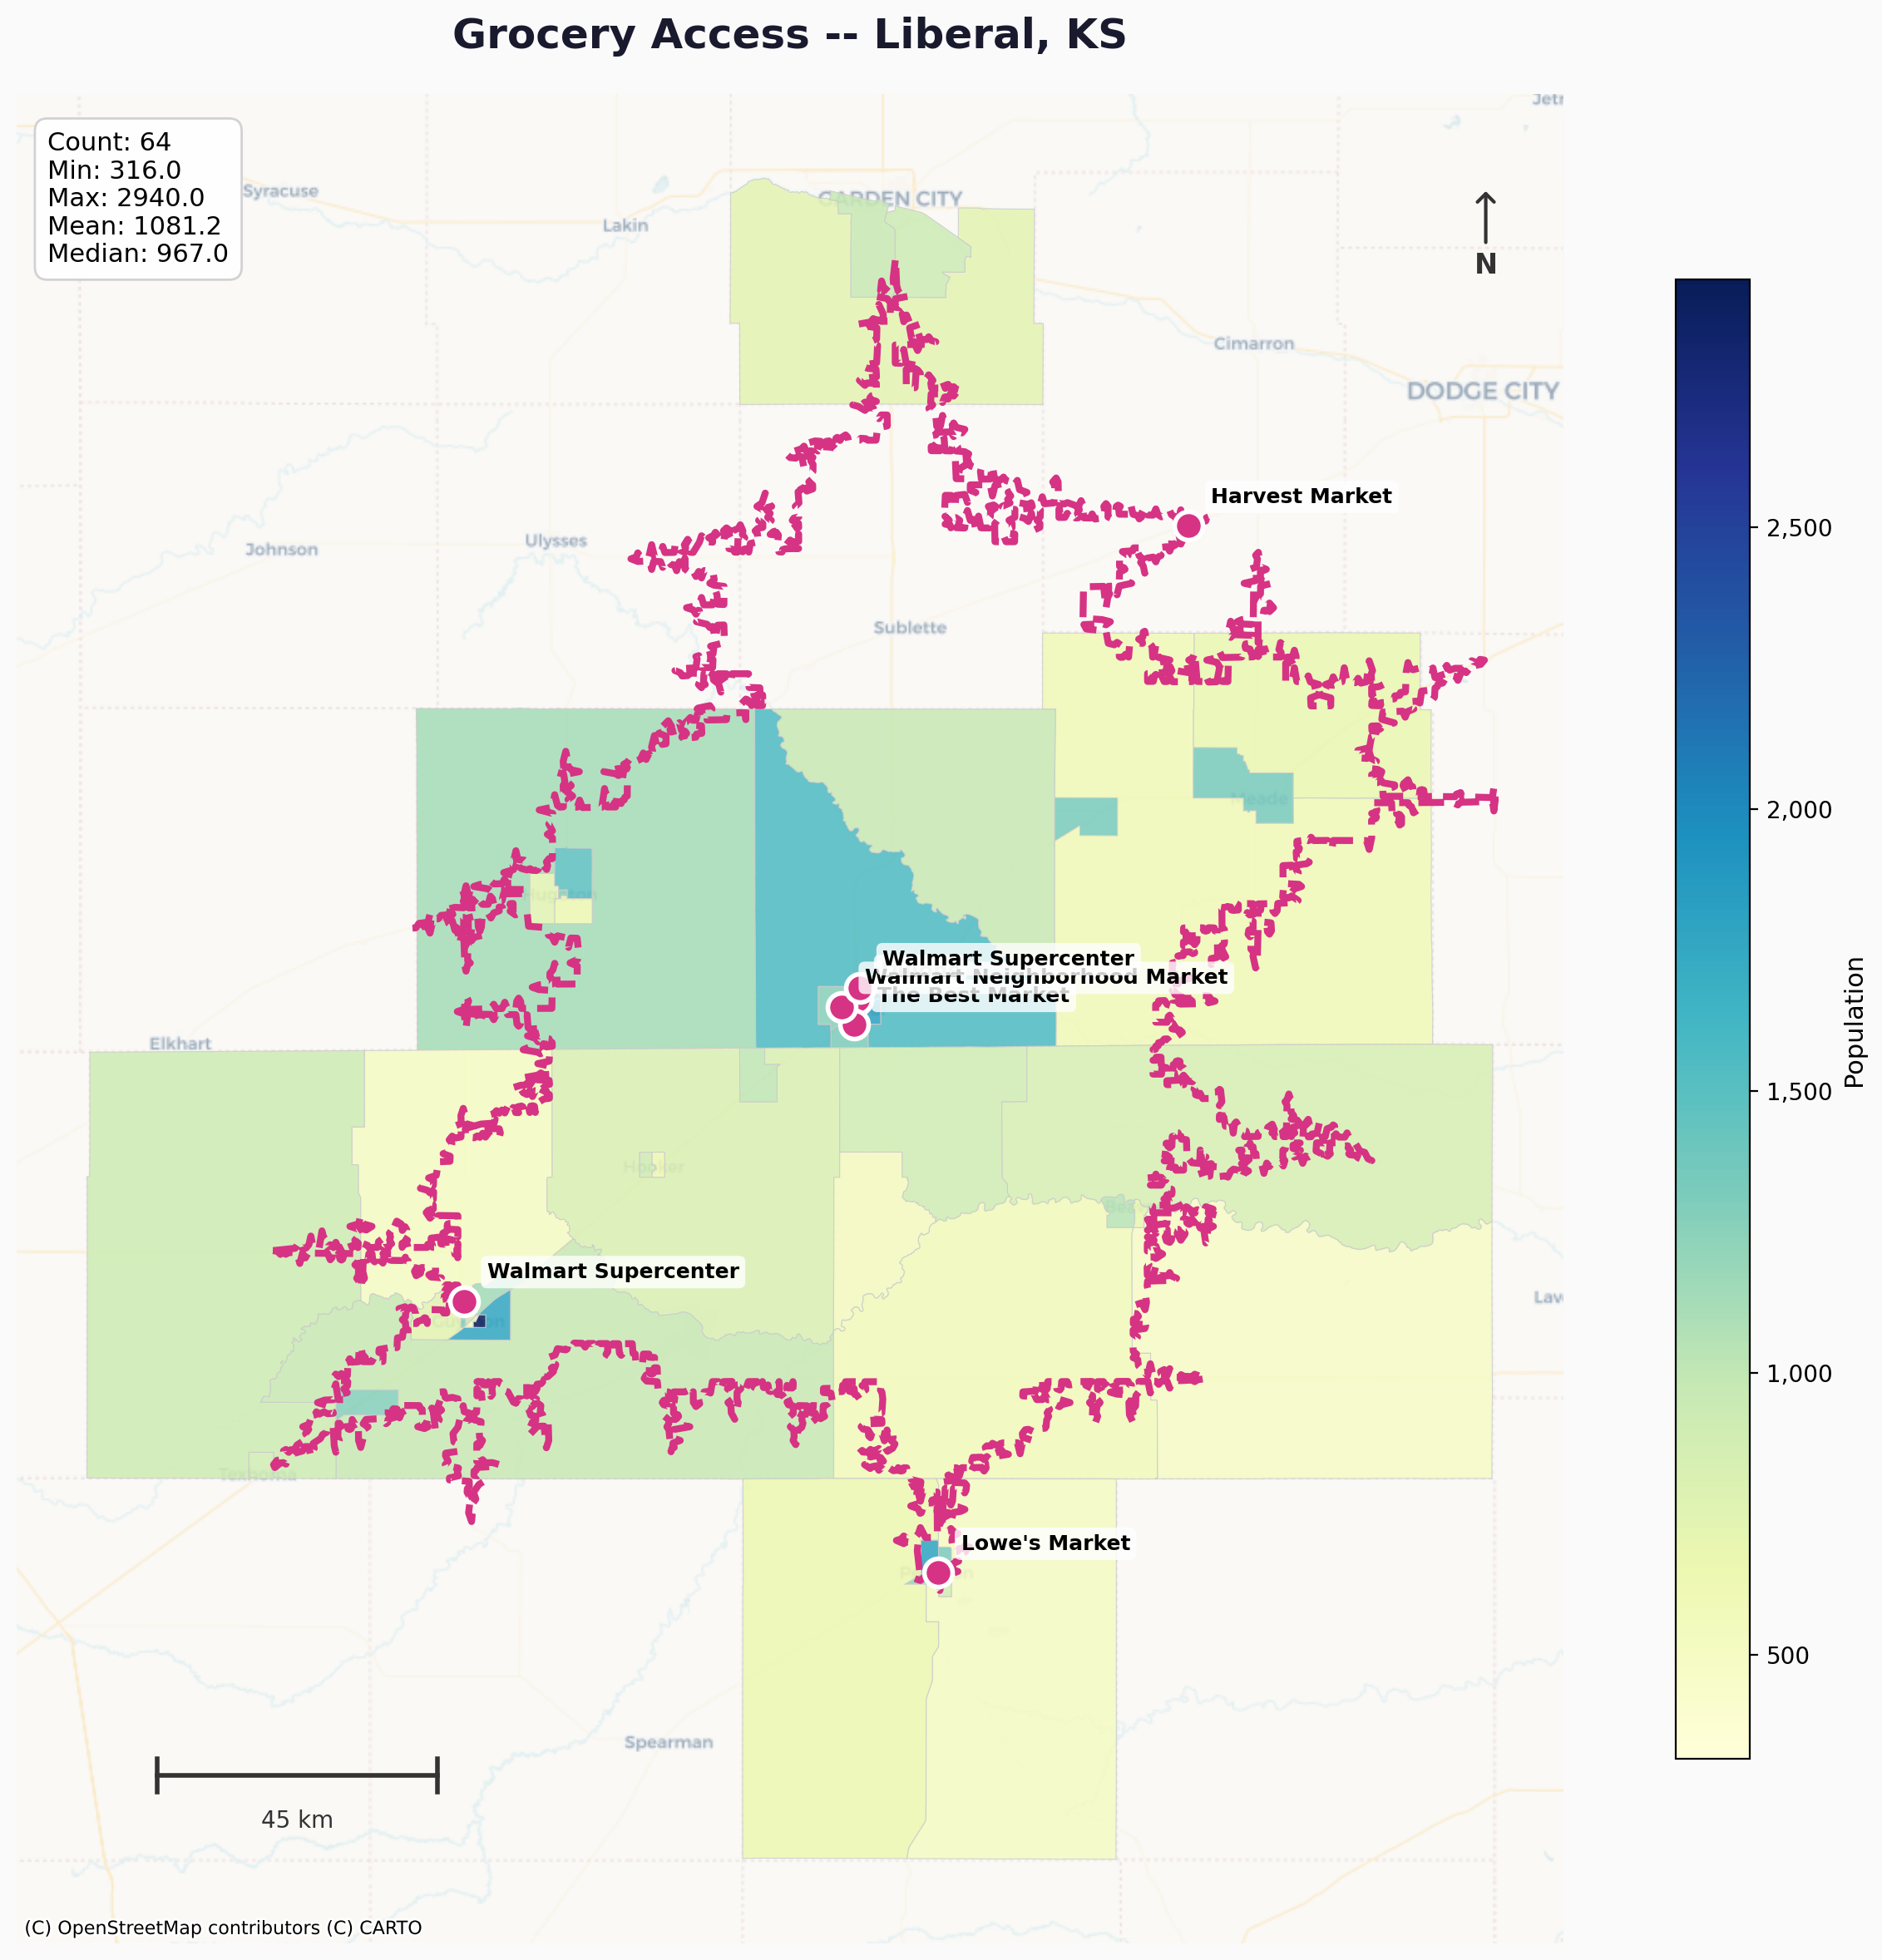

In [10]:
for name in towns:
    # Overlay all grocery stores as points
    overlay_points = [
        {"lat": s["lat"], "lon": s["lon"], "name": s["name"]}
        for s in grocery_stores[name]
    ]

    map_result = create_map(
        data=merged_data[name],
        column="population",
        title=f"Grocery Access -- {name}",
        overlay_boundary=isochrones[name],
        overlay_points=overlay_points,
        show_stats=True,
    )
    print(f"\n--- {name} ({len(grocery_stores[name])} grocery stores shown) ---")
    display(Image(data=map_result.image_data))

### Reading the Maps

The maps confirm the hub-and-spoke pattern found in NB08. Grocery stores cluster tightly within the town centers. The vast surrounding area -- block groups spanning hundreds of square miles of farmland -- has zero grocery stores. Residents in outlying areas have exactly one destination for food: the hub town.

The darker block groups (higher population) are in and around the town itself. The lighter, physically enormous block groups surrounding them represent sparse rural population. When the hub town loses a major grocery store, these outlying residents are the most affected -- they already drive 20--40 minutes to reach town, and now they face fewer options when they arrive.

---

## Step 9: Per-Capita Analysis -- Grocery Stores per 10,000 People

Raw store counts do not account for population. A town with 5 stores serving 20,000 people is better off than a town with 5 stores serving 90,000 people. We calculate **grocery stores per 10,000 residents** to normalize the comparison, then show how the closure scenario changes the ratio.

Hays, KS:
  Population:           60,725.0
  Local stores before:  4 (0.66 per 10k)
  Local stores after:   2 (0.33 per 10k)
  Change:               -0.33 per 10k

Dodge City, KS:
  Population:           88,678.0
  Local stores before:  3 (0.34 per 10k)
  Local stores after:   2 (0.23 per 10k)
  Change:               -0.11 per 10k

Liberal, KS:
  Population:           69,195.0
  Local stores before:  4 (0.58 per 10k)
  Local stores after:   2 (0.29 per 10k)
  Change:               -0.29 per 10k



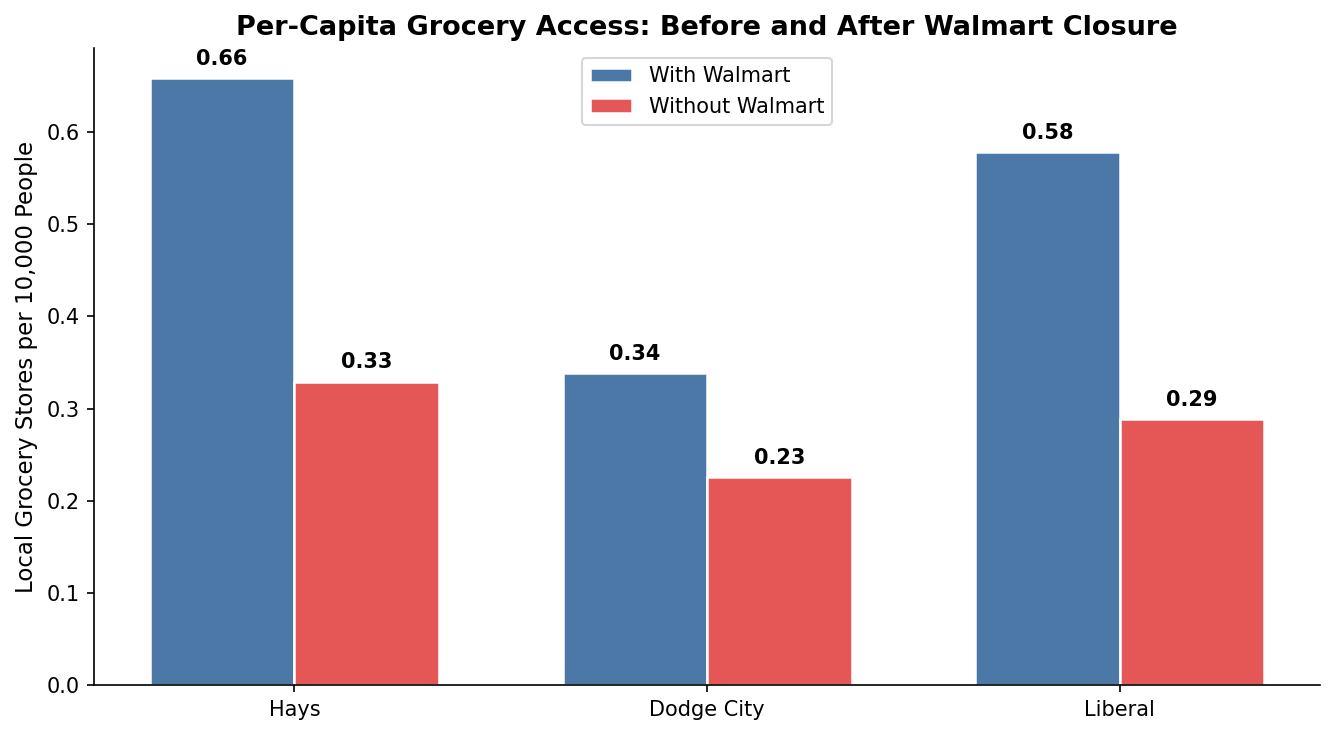

In [11]:
per_capita = {}

for name in towns:
    total_pop = sum(
        d.get("population", 0)
        for d in census_data[name].data.values()
        if d.get("population") is not None
    )

    local_before = closure[name]["local_before"]
    local_after = closure[name]["local_after"]

    rate_before = (local_before / total_pop * 10000) if total_pop > 0 else 0
    rate_after = (local_after / total_pop * 10000) if total_pop > 0 else 0

    per_capita[name] = {
        "population": total_pop,
        "rate_before": rate_before,
        "rate_after": rate_after,
    }

    print(f"{name}:")
    print(f"  Population:           {total_pop:,}")
    print(f"  Local stores before:  {local_before} ({rate_before:.2f} per 10k)")
    print(f"  Local stores after:   {local_after} ({rate_after:.2f} per 10k)")
    print(f"  Change:               {rate_after - rate_before:+.2f} per 10k")
    print()

# Grouped bar chart: per-capita before and after
fig, ax = plt.subplots(figsize=(9, 5))
town_labels = [n.replace(", KS", "") for n in towns]
x = np.arange(len(town_labels))
width = 0.35

rates_before = [per_capita[n]["rate_before"] for n in towns]
rates_after = [per_capita[n]["rate_after"] for n in towns]

bars1 = ax.bar(x - width / 2, rates_before, width, label="With Walmart",
               color="#4c78a8", edgecolor="white", linewidth=1.2)
bars2 = ax.bar(x + width / 2, rates_after, width, label="Without Walmart",
               color="#e45756", edgecolor="white", linewidth=1.2)

for bar, val in zip(bars1, rates_before):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar, val in zip(bars2, rates_after):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(town_labels)
ax.set_ylabel("Local Grocery Stores per 10,000 People")
ax.set_title("Per-Capita Grocery Access: Before and After Walmart Closure", fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Per-Capita Findings

The per-capita view adds nuance to the raw counts. Even before a closure, these communities have extremely low grocery density -- fractions of a store per 10,000 people. For comparison, the USDA considers a census tract a "food desert" when the nearest supermarket is more than 10 miles away; by that standard, the vast majority of the land area within these 60-minute isochrones already qualifies.

The closure scenario reduces per-capita access across all three towns, but the relative impact varies:

- **Dodge City** has the lowest per-capita access both before and after, because it serves the largest population (~89,000)
- **Liberal** experiences the steepest proportional drop, losing half its local grocery per-capita rate
- **Hays** falls somewhere in between

These numbers are already at the margin. Losing even one store per 10,000 people -- when you started with fewer than one -- is the difference between strained access and no access.

---

## Key Findings

Consolidating the analysis into a final summary.

In [12]:
print("=" * 65)
print("WALMART CLOSURE GROCERY ACCESS ASSESSMENT")
print("Western Kansas: Hays, Dodge City, Liberal (60-min drive)")
print("=" * 65)

for name in towns:
    total_pop = per_capita[name]["population"]
    dep = dependency[name]
    clos = closure[name]
    pc = per_capita[name]

    print(f"\n--- {name} ---")
    print(f"  Community population:    {total_pop:,}")
    print(f"  Local grocery stores:    {dep['total_local']} (within 10 min)")
    print(f"  Walmart share:           {dep['walmart_count']} of {dep['total_local']} ({dep['walmart_pct']:.0f}%)")
    print(f"  After closure:           {clos['local_after']} local stores remain")
    print(f"  Per-capita rate:         {pc['rate_before']:.2f} -> {pc['rate_after']:.2f} per 10k")
    if clos["nearest_distant"]:
        nd = clos["nearest_distant"]
        print(f"  Next non-local option:   {nd['name']} ({nd.get('travel_time_minutes', '?'):.1f} min)")
    print(f"  Total grocery (60-min):  {clos['total_before']} -> {clos['total_after']}")

print("\n" + "=" * 65)
print("BOTTOM LINE")
print("=" * 65)
print()
print("Walmart is not just a store in rural Kansas -- it is infrastructure.")
print("Losing it does not just reduce competition; it eliminates access.")
print()
print("Liberal is the most vulnerable:")
print(f"  - 50% of local grocery is Walmart")
print(f"  - Next alternative is 44+ minutes away")
print(f"  - Highest poverty rate (~14%) means least ability to absorb costs")
print(f"  - ~69,000 people in the affected community")

WALMART CLOSURE GROCERY ACCESS ASSESSMENT
Western Kansas: Hays, Dodge City, Liberal (60-min drive)

--- Hays, KS ---
  Community population:    60,725.0
  Local grocery stores:    4 (within 10 min)
  Walmart share:           2 of 4 (50%)
  After closure:           2 local stores remain
  Per-capita rate:         0.66 -> 0.33 per 10k
  Next non-local option:   Rick's Food Store (27.1 min)
  Total grocery (60-min):  10 -> 8

--- Dodge City, KS ---
  Community population:    88,678.0
  Local grocery stores:    3 (within 10 min)
  Walmart share:           1 of 3 (33%)
  After closure:           2 local stores remain
  Per-capita rate:         0.34 -> 0.23 per 10k
  Next non-local option:   Harvest Market (30.3 min)
  Total grocery (60-min):  12 -> 9

--- Liberal, KS ---
  Community population:    69,195.0
  Local grocery stores:    4 (within 10 min)
  Walmart share:           2 of 4 (50%)
  After closure:           2 local stores remain
  Per-capita rate:         0.58 -> 0.29 per 10k
  Nex

### What the Data Tells Us

1. **Walmart is grocery infrastructure in rural Kansas.** In all three towns, Walmart represents 33--50% of local grocery stores. This is not a market with many competitors where one player exits -- it is a thin market where losing one player can mean losing a third to half of all access.

2. **The dead zone is the critical vulnerability.** Grocery stores do not spread evenly across the landscape. They cluster within 10 minutes of town center, then disappear for 20--40 minutes. There is no middle ground. If you lose a local store, the next option is not "a little farther" -- it is 30+ minutes farther.

3. **Liberal is the most exposed.** With two Walmart locations accounting for half of local grocery, the highest poverty rate (~14%), and a 58-minute gap to the next non-Walmart alternative, Liberal would be the hardest hit by a Walmart closure. The only closer fallback is a Walmart in Guymon, Oklahoma (44 min) -- which would also close in a regional pullback.

4. **Per-capita grocery access is already at the margin.** All three towns have fewer than 1 local grocery store per 10,000 people. Losing even one store drops the rate further into territory that urban food-desert definitions would flag as a crisis. Dodge City, serving ~89,000 people with just 3 local stores, has the lowest per-capita rate at 0.34 per 10,000.

5. **This is a systemic pattern, not a local anomaly.** The hub-and-spoke structure of Great Plains towns -- services clustered in town, vast empty hinterland -- means that any hub town with a single dominant grocery provider faces the same vulnerability. Hays, Dodge City, and Liberal are representative, not exceptional.

6. **The policy question is not about Walmart.** It is about what happens when rural communities depend on a single corporation for essential services with no public fallback. Hospitals, pharmacies, and schools face the same structural vulnerability as grocery stores. The question is whether communities, states, and federal programs have contingency plans for when the market withdraws from places it no longer finds profitable.

---

## Limitations

- **OpenStreetMap completeness**: Rural OSM coverage is imperfect. Some small-town stores may be missing entirely. The keyword filter catches common names but cannot discover stores with unusual names that lack grocery-related keywords.

- **Keyword filter false positives**: The broad keyword list (especially `"market"`) may match non-grocery businesses like "flea market" or "farmers market" (seasonal). Manual review of results is recommended for policy decisions.

- **Store size and selection**: This analysis counts stores, not square footage or product selection. A Walmart Supercenter with 120,000 sq ft of grocery is not equivalent to a 5,000 sq ft small-town food store. The closure impact is worse than raw counts suggest because Walmart carries more products at lower prices.

- **ACS margins of error**: Census block group data in rural areas has large confidence intervals. Population and income figures are approximate.

- **Static snapshot**: OSM data reflects the current state. Store openings and closings happen continuously. Results should be re-run periodically to track changes.

- **Cross-state stores**: Liberal's grocery area extends into Oklahoma. The 60-minute search correctly finds stores like the Walmart in Guymon, OK, but census data is limited to the Kansas-side block groups.

---

## API Cheat Sheet

Quick reference for SocialMapper functions used in this notebook:

| Function | Purpose | Key Parameters |
|---|---|---|
| `get_poi(location, categories, ...)` | Search OpenStreetMap POIs within travel-time boundary | `travel_time`, `travel_mode`, `limit` |
| `create_isochrone(location, travel_time, travel_mode)` | Travel-time polygon from a point | `travel_mode`: `"walk"`, `"drive"`, `"bike"` |
| `get_census_blocks(polygon=iso)` | Census block groups intersecting an area | Pass an isochrone or GeoJSON dict |
| `get_census_data(location, variables)` | ACS demographic data by block group | `"population"`, `"median_income"`, `"poverty"` |
| `create_map(data, column, ...)` | Choropleth map with optional overlays | `overlay_boundary`, `overlay_points`, `show_stats` |

---

*This notebook was created as part of the SocialMapper tutorial series. See [Notebook 08](08-rural-community-mapping.ipynb) for the broader rural community mapping analysis these towns are drawn from. For more information, see the [SocialMapper documentation](https://github.com/mihiarc/socialmapper).*